In [45]:
# Import standard libraries
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Data and Vocabularies

In [46]:
# Load data and utilities
from src.data_loader import load_data, create_dataloaders, create_bert_dataloaders
from src.utils import build_vocab, load_slot_vocab, load_intent_vocab, compute_slot_f1

# Load datasets
train_data = load_data('dataset/train')
val_data = load_data('dataset/valid')
test_data = load_data('dataset/test')

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")
print(f"\nSample data: {train_data[0]}")

Train samples: 13084
Validation samples: 700
Test samples: 700

Sample data: {'intent_label': 'AddToPlaylist', 'words': ['Add', 'Don', 'and', 'Sherri', 'to', 'my', 'Meditate', 'to', 'Sounds', 'of', 'Nature', 'playlist'], 'slot_labels': ['O', 'B-entity_name', 'I-entity_name', 'I-entity_name', 'O', 'B-playlist_owner', 'B-playlist', 'I-playlist', 'I-playlist', 'I-playlist', 'I-playlist', 'O'], 'length': 12}


In [47]:
# Load vocabularies
intent_vocab = load_intent_vocab('dataset/vocab.intent')
slot_vocab = load_slot_vocab('dataset/vocab.slot')

# Build word vocabulary from training data only
train_sentences = [' '.join(item['words']) for item in train_data]
word_vocab = build_vocab(train_sentences, min_freq=1)

print(f"Intent classes: {len(intent_vocab)}")
print(f"Slot labels: {len(slot_vocab)}")
print(f"Vocabulary size: {len(word_vocab)}")
print(f"\nIntent labels: {list(intent_vocab.keys())}")

Intent classes: 7
Slot labels: 73
Vocabulary size: 13456

Intent labels: ['AddToPlaylist', 'BookRestaurant', 'GetWeather', 'PlayMusic', 'RateBook', 'SearchCreativeWork', 'SearchScreeningEvent']


## 2. Define Training and Evaluation Functions

In [48]:
def train_joint_model(
    model, 
    train_loader, 
    val_loader, 
    epochs=20, 
    lr=1e-3,
    slot_pad_idx=0,
    alpha=1.0,  # weight for intent loss
    beta=1.0,   # weight for slot loss
    clip_grad=5.0,
    patience=3,  # early stopping patience
    min_delta=1e-4  # minimum change to qualify as improvement
):
    """
    Train a joint intent classification and slot filling model.
    
    Args:
        model: The joint NLU model
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
        epochs: Maximum number of training epochs
        lr: Learning rate
        slot_pad_idx: Padding index for slot labels (ignored in loss)
        alpha: Weight for intent classification loss
        beta: Weight for slot filling loss
        clip_grad: Maximum gradient norm for clipping
        patience: Number of epochs to wait before early stopping
        min_delta: Minimum change in validation loss to qualify as improvement
    """
    model = model.to(device)
    
    # Loss functions
    intent_criterion = nn.CrossEntropyLoss()
    slot_criterion = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    
    optimizer = Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'intent_acc': [], 'slot_f1': []}
    
    # Early stopping variables
    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stopped = False
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_train_loss = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intent_labels = batch['intent_label'].to(device)
            slot_labels = batch['slot_labels'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            intent_logits, slot_logits = model(input_ids, attention_mask)
            
            # Compute losses
            intent_loss = intent_criterion(intent_logits, intent_labels)
            # Reshape slot logits for cross entropy: (batch * seq_len, num_slots)
            slot_logits_flat = slot_logits.view(-1, slot_logits.size(-1))
            slot_labels_flat = slot_labels.view(-1)
            slot_loss = slot_criterion(slot_logits_flat, slot_labels_flat)
            
            # Combined loss
            total_loss = alpha * intent_loss + beta * slot_loss
            
            # Backward pass
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            
            total_train_loss += total_loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Validation phase
        val_metrics = evaluate_joint_model(model, val_loader, slot_pad_idx, slot_vocab)
        history['val_loss'].append(val_metrics['total_loss'])
        history['intent_acc'].append(val_metrics['intent_accuracy'])
        history['slot_f1'].append(val_metrics['slot_f1'])
        
        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {val_metrics['total_loss']:.4f}")
        print(f"  Intent Accuracy: {val_metrics['intent_accuracy']:.4f}")
        print(f"  Slot F1: {val_metrics['slot_f1']:.4f}")
        print(f"  Joint Accuracy: {val_metrics['joint_accuracy']:.4f}")
        
        # Early stopping check
        if val_metrics['total_loss'] < best_val_loss - min_delta:
            best_val_loss = val_metrics['total_loss']
            epochs_no_improve = 0
            print(f"  ✓ New best validation loss: {best_val_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve} epoch(s)")
            
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs!")
                early_stopped = True
                break
        
        print()
    
    if not early_stopped:
        print(f"Training completed all {epochs} epochs")
    
    return history


In [49]:
def evaluate_joint_model(model, data_loader, slot_pad_idx=0, slot_vocab=None):
    """
    Evaluate a joint intent classification and slot filling model.
    
    Returns:
        Dictionary with metrics: total_loss, intent_accuracy, slot_f1, joint_accuracy
    """
    model = model.to(device)
    model.eval()
    
    intent_criterion = nn.CrossEntropyLoss()
    slot_criterion = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    
    total_loss = 0
    intent_correct = 0
    intent_total = 0
    joint_correct = 0
    
    all_slot_preds = []
    all_slot_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intent_labels = batch['intent_label'].to(device)
            slot_labels = batch['slot_labels'].to(device)
            
            # Forward pass
            intent_logits, slot_logits = model(input_ids, attention_mask)
            
            # Compute losses
            intent_loss = intent_criterion(intent_logits, intent_labels)
            slot_logits_flat = slot_logits.view(-1, slot_logits.size(-1))
            slot_labels_flat = slot_labels.view(-1)
            slot_loss = slot_criterion(slot_logits_flat, slot_labels_flat)
            total_loss += (intent_loss + slot_loss).item()
            
            # Intent predictions
            intent_preds = torch.argmax(intent_logits, dim=1)
            intent_correct += (intent_preds == intent_labels).sum().item()
            intent_total += intent_labels.size(0)
            
            # Slot predictions
            slot_preds = torch.argmax(slot_logits, dim=2)  # (batch, seq_len)
            
            # Collect for F1 computation
            for i in range(slot_preds.size(0)):
                pred_seq = slot_preds[i].cpu().tolist()
                label_seq = slot_labels[i].cpu().tolist()
                all_slot_preds.append(pred_seq)
                all_slot_labels.append(label_seq)
                
                # Joint accuracy: both intent and all slots correct
                intent_match = (intent_preds[i] == intent_labels[i]).item()
                # Compare only non-padding slots
                slot_match = all(
                    p == l for p, l in zip(pred_seq, label_seq) 
                    if l != slot_pad_idx
                )
                if intent_match and slot_match:
                    joint_correct += 1
    
    # Compute metrics
    avg_loss = total_loss / len(data_loader)
    intent_accuracy = intent_correct / intent_total
    joint_accuracy = joint_correct / intent_total
    
    # Compute slot F1
    if slot_vocab is not None:
        _, _, slot_f1 = compute_slot_f1(
            all_slot_preds, 
            all_slot_labels, 
            slot_vocab, 
            ignore_index=slot_pad_idx
        )
    else:
        slot_f1 = 0.0
    
    return {
        'total_loss': avg_loss,
        'intent_accuracy': intent_accuracy,
        'slot_f1': slot_f1,
        'joint_accuracy': joint_accuracy
    }

## 3. Model 1: Encoder-Decoder with Learned Embeddings

In [50]:
from src.models import EncoderDecoderNLU

# Create DataLoaders for Encoder-Decoder & Transformer models
MAX_LEN = 50
BATCH_SIZE = 32

train_loader, val_loader, test_loader = create_dataloaders(
    train_data, val_data, test_data,
    word_vocab, slot_vocab, intent_vocab,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 409
Validation batches: 22
Test batches: 22


In [51]:
# Initialize Encoder-Decoder model
model1 = EncoderDecoderNLU(
    vocab_size=len(word_vocab),
    embedding_dim=300,
    hidden_dim=128,
    num_intents=len(intent_vocab),
    num_slots=len(slot_vocab),
    n_layers=1,
    dropout=0.3,
    pad_idx=word_vocab['<PAD>']
)

print(f"Encoder-Decoder parameters: {sum(p.numel() for p in model1.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}")

Encoder-Decoder parameters: 4,608,272
Trainable parameters: 4,608,272


In [52]:
# Train Encoder-Decoder model
history1 = train_joint_model(
    model1, 
    train_loader, 
    val_loader,
    epochs=5,
    lr=1e-3,
    slot_pad_idx=slot_vocab['<PAD>']
)

Epoch 1/5 [Train]:   0%|          | 0/409 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 22/22 [00:00<00:00, 119.70it/s]


Epoch 1/5:
  Train Loss: 1.5405
  Val Loss: 0.5260
  Intent Accuracy: 0.9857
  Slot F1: 0.7841
  Joint Accuracy: 0.4157
  ✓ New best validation loss: 0.5260



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 163.13it/s]


Epoch 2/5:
  Train Loss: 0.4826
  Val Loss: 0.3425
  Intent Accuracy: 0.9857
  Slot F1: 0.8492
  Joint Accuracy: 0.5486
  ✓ New best validation loss: 0.3425



...

Epoch 3/5:
  Train Loss: 0.3221
  Val Loss: 0.3078
  Intent Accuracy: 0.9857
  Slot F1: 0.8713
  Joint Accuracy: 0.6000
  ✓ New best validation loss: 0.3078



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 139.09it/s]


Epoch 4/5:
  Train Loss: 0.2482
  Val Loss: 0.3193
  Intent Accuracy: 0.9829
  Slot F1: 0.8810
  Joint Accuracy: 0.6243
  No improvement for 1 epoch(s)



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 160.59it/s]

Epoch 5/5:
  Train Loss: 0.2010
  Val Loss: 0.3241
  Intent Accuracy: 0.9843
  Slot F1: 0.8805
  Joint Accuracy: 0.6229
  No improvement for 2 epoch(s)

Training completed all 5 epochs


In [53]:
# Evaluate Encoder-Decoder model on test set
print("Encoder-Decoder (Learned Embeddings) - Test Set Evaluation:")
test_metrics1 = evaluate_joint_model(model1, test_loader, slot_vocab['<PAD>'], slot_vocab)
print(f"  Intent Accuracy: {test_metrics1['intent_accuracy']:.4f}")
print(f"  Slot F1: {test_metrics1['slot_f1']:.4f}")
print(f"  Joint Accuracy: {test_metrics1['joint_accuracy']:.4f}")

Encoder-Decoder (Learned Embeddings) - Test Set Evaluation:


Evaluating: 100%|██████████| 22/22 [00:00<00:00, 167.40it/s]

  Intent Accuracy: 0.9771
  Slot F1: 0.8716
  Joint Accuracy: 0.6129


## 4. Model 2: Transformer with Multi-Head Attention

In [54]:
from src.models import TransformerNLU

# Initialize Transformer model
model2 = TransformerNLU(
    vocab_size=len(word_vocab),
    d_model=256,  # Smaller model for faster training
    nhead=8,
    num_encoder_layers=4,
    dim_feedforward=1024,
    num_intents=len(intent_vocab),
    num_slots=len(slot_vocab),
    max_len=MAX_LEN,
    dropout=0.1,
    pad_idx=word_vocab['<PAD>']
)

print(f"Transformer parameters: {sum(p.numel() for p in model2.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")

Transformer parameters: 6,656,336
Trainable parameters: 6,656,336


In [55]:
# Train Transformer model
history2 = train_joint_model(
    model2, 
    train_loader, 
    val_loader,
    epochs=10,
    lr=5e-4,  # Lower LR for transformer
    slot_pad_idx=slot_vocab['<PAD>']
)

Evaluating: 100%|██████████| 22/22 [00:00<00:00, 147.12it/s]


Epoch 1/10:
  Train Loss: 1.1227
  Val Loss: 0.5166
  Intent Accuracy: 0.9786
  Slot F1: 0.7578
  Joint Accuracy: 0.3643
  ✓ New best validation loss: 0.5166



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 145.61it/s]


Epoch 2/10:
  Train Loss: 0.3682
  Val Loss: 0.5017
  Intent Accuracy: 0.9871
  Slot F1: 0.8190
  Joint Accuracy: 0.4471
  ✓ New best validation loss: 0.5017



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 153.12it/s]


Epoch 3/10:
  Train Loss: 0.1878
  Val Loss: 0.5655
  Intent Accuracy: 0.9829
  Slot F1: 0.8515
  Joint Accuracy: 0.5057
  No improvement for 1 epoch(s)



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 149.31it/s]


Epoch 4/10:
  Train Loss: 0.1126
  Val Loss: 0.5029
  Intent Accuracy: 0.9843
  Slot F1: 0.8715
  Joint Accuracy: 0.5471
  No improvement for 2 epoch(s)



Evaluating: 100%|██████████| 22/22 [00:00<00:00, 153.07it/s]

Epoch 5/10:
  Train Loss: 0.0854
  Val Loss: 0.5191
  Intent Accuracy: 0.9814
  Slot F1: 0.8708
  Joint Accuracy: 0.5557
  No improvement for 3 epoch(s)

Early stopping triggered after 5 epochs!


In [56]:
# Evaluate Transformer model on test set
print("Transformer (Multi-Head Attention) - Test Set Evaluation:")
test_metrics2 = evaluate_joint_model(model2, test_loader, slot_vocab['<PAD>'], slot_vocab)
print(f"  Intent Accuracy: {test_metrics2['intent_accuracy']:.4f}")
print(f"  Slot F1: {test_metrics2['slot_f1']:.4f}")
print(f"  Joint Accuracy: {test_metrics2['joint_accuracy']:.4f}")

Transformer (Multi-Head Attention) - Test Set Evaluation:


Evaluating: 100%|██████████| 22/22 [00:00<00:00, 114.30it/s]

  Intent Accuracy: 0.9814
  Slot F1: 0.8592
  Joint Accuracy: 0.5614


## 5. Model 3: Encoder-Decoder with Frozen BERT Embeddings

In [57]:
from transformers import BertTokenizer
from src.models import BertEncoderDecoderNLU

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

# Create BERT DataLoaders with subword alignment
bert_train_loader, bert_val_loader, bert_test_loader = create_bert_dataloaders(
    train_data, val_data, test_data,
    tokenizer, slot_vocab, intent_vocab,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN
)

print(f"BERT Training batches: {len(bert_train_loader)}")

BERT Training batches: 409


In [58]:
# Initialize BERT + Encoder-Decoder model
model3 = BertEncoderDecoderNLU(
    hidden_dim=128,
    num_intents=len(intent_vocab),
    num_slots=len(slot_vocab),
    n_layers=1,
    dropout=0.3,
    bert_model_name='bert-base-cased'
)

total_params = sum(p.numel() for p in model3.parameters())
trainable_params = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f"BERT + Encoder-Decoder total parameters: {total_params:,}")
print(f"BERT + Encoder-Decoder trainable parameters: {trainable_params:,}")
print(f"BERT parameters (frozen): {total_params - trainable_params:,}")

Loading BERT model 'bert-base-cased'... This may take a moment.
BERT model loaded and frozen successfully!
BERT + Encoder-Decoder total parameters: 109,420,880
BERT + Encoder-Decoder trainable parameters: 1,110,608
BERT parameters (frozen): 108,310,272


In [59]:
# For BERT + Encoder-Decoder model, we need to use -100 as ignore index (for subword alignment)
def train_bert_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    """Training function for BERT model with -100 ignore index."""
    model = model.to(device)
    
    intent_criterion = nn.CrossEntropyLoss()
    slot_criterion = nn.CrossEntropyLoss(ignore_index=-100)  # Ignore special tokens
    
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    # Track training history
    history = {'train_loss': [], 'val_loss': [], 'intent_acc': [], 'slot_acc': []}
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intent_labels = batch['intent_label'].to(device)
            slot_labels = batch['slot_labels'].to(device)
            
            optimizer.zero_grad()
            
            intent_logits, slot_logits = model(input_ids, attention_mask)
            
            intent_loss = intent_criterion(intent_logits, intent_labels)
            slot_logits_flat = slot_logits.view(-1, slot_logits.size(-1))
            slot_labels_flat = slot_labels.view(-1)
            slot_loss = slot_criterion(slot_logits_flat, slot_labels_flat)
            
            total_loss = intent_loss + slot_loss
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            total_train_loss += total_loss.item()
        
        # Validation
        model.eval()
        val_intent_correct = 0
        val_slot_correct = 0
        val_slot_total = 0
        val_total = 0
        val_total_loss = 0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                intent_labels = batch['intent_label'].to(device)
                slot_labels = batch['slot_labels'].to(device)
                
                intent_logits, slot_logits = model(input_ids, attention_mask)
                
                # Compute validation loss
                intent_loss = intent_criterion(intent_logits, intent_labels)
                slot_logits_flat = slot_logits.view(-1, slot_logits.size(-1))
                slot_labels_flat = slot_labels.view(-1)
                slot_loss = slot_criterion(slot_logits_flat, slot_labels_flat)
                val_total_loss += (intent_loss + slot_loss).item()
                
                # Intent accuracy
                intent_preds = torch.argmax(intent_logits, dim=1)
                val_intent_correct += (intent_preds == intent_labels).sum().item()
                val_total += intent_labels.size(0)
                
                # Slot accuracy (only non-ignored positions)
                slot_preds = torch.argmax(slot_logits, dim=2)
                mask = slot_labels != -100
                val_slot_correct += ((slot_preds == slot_labels) & mask).sum().item()
                val_slot_total += mask.sum().item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = val_total_loss / len(val_loader)
        val_intent_acc = val_intent_correct / val_total
        val_slot_acc = val_slot_correct / val_slot_total if val_slot_total > 0 else 0.0
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['intent_acc'].append(val_intent_acc)
        history['slot_acc'].append(val_slot_acc)
        
        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, "
              f"Val Loss = {avg_val_loss:.4f}, "
              f"Val Intent Acc = {val_intent_acc:.4f}, "
              f"Val Slot Acc = {val_slot_acc:.4f}")
    
    return history

In [60]:
# Train BERT + Encoder-Decoder model
history3 = train_bert_model(model3, bert_train_loader, bert_val_loader, epochs=5, lr=1e-3)

Epoch 1/5 [Val]: 100%|██████████| 22/22 [00:01<00:00, 12.15it/s]


Epoch 1: Train Loss = 1.1464, Val Loss = 0.3155, Val Intent Acc = 0.9700, Val Slot Acc = 0.9348


Epoch 2/5 [Val]: 100%|██████████| 22/22 [00:01<00:00, 11.23it/s]


Epoch 2: Train Loss = 0.3310, Val Loss = 0.2232, Val Intent Acc = 0.9786, Val Slot Acc = 0.9548


Epoch 3/5 [Val]: 100%|██████████| 22/22 [00:02<00:00, 10.75it/s]


Epoch 3: Train Loss = 0.2464, Val Loss = 0.2308, Val Intent Acc = 0.9771, Val Slot Acc = 0.9577


Epoch 4/5 [Val]: 100%|██████████| 22/22 [00:02<00:00, 10.75it/s]


Epoch 4: Train Loss = 0.2072, Val Loss = 0.1774, Val Intent Acc = 0.9843, Val Slot Acc = 0.9657


Epoch 5/5 [Val]: 100%|██████████| 22/22 [00:02<00:00, 10.92it/s]

Epoch 5: Train Loss = 0.1788, Val Loss = 0.1850, Val Intent Acc = 0.9800, Val Slot Acc = 0.9660


In [61]:
# Evaluate BERT + Encoder-Decoder model on test set
def evaluate_bert_model(model, data_loader):
    """Evaluate BERT model."""
    model = model.to(device)
    model.eval()
    
    intent_correct = 0
    slot_correct = 0
    slot_total = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Testing"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intent_labels = batch['intent_label'].to(device)
            slot_labels = batch['slot_labels'].to(device)
            
            intent_logits, slot_logits = model(input_ids, attention_mask)
            
            # Intent accuracy
            intent_preds = torch.argmax(intent_logits, dim=1)
            intent_correct += (intent_preds == intent_labels).sum().item()
            total += intent_labels.size(0)
            
            # Slot accuracy (only non-ignored positions)
            slot_preds = torch.argmax(slot_logits, dim=2)
            mask = slot_labels != -100
            slot_correct += ((slot_preds == slot_labels) & mask).sum().item()
            slot_total += mask.sum().item()
    
    print(f"Intent Accuracy: {intent_correct/total:.4f}")
    print(f"Slot Accuracy: {slot_correct/slot_total:.4f}")

print("BERT + Encoder-Decoder (Frozen Embeddings) - Test Set Evaluation:")
evaluate_bert_model(model3, bert_test_loader)

BERT + Encoder-Decoder (Frozen Embeddings) - Test Set Evaluation:


Testing: 100%|██████████| 22/22 [00:02<00:00, 10.89it/s]

Intent Accuracy: 0.9857
Slot Accuracy: 0.9686


## 5. Training Visualizations and Analysis

In [62]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

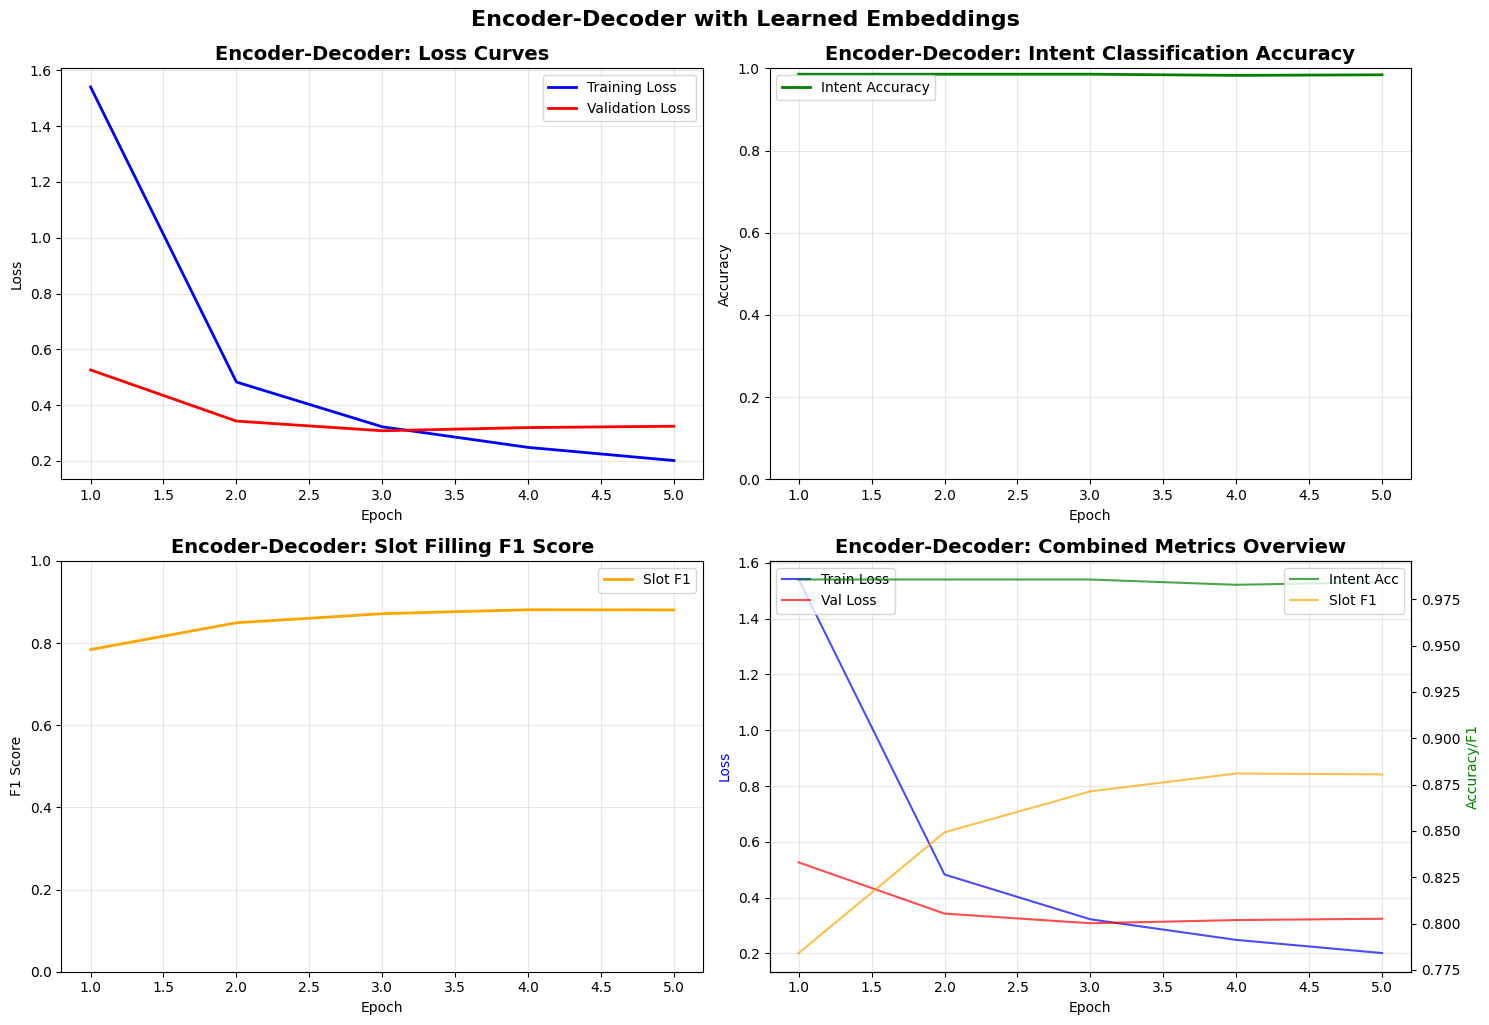

In [63]:
# Encoder-Decoder (Learned Embeddings) Training Curves
if 'history1' in locals():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history1['train_loss']) + 1)
    
    # Loss curves
    ax1.plot(epochs, history1['train_loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history1['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('Encoder-Decoder: Loss Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Intent Accuracy
    ax2.plot(epochs, history1['intent_acc'], 'g-', label='Intent Accuracy', linewidth=2)
    ax2.set_title('Encoder-Decoder: Intent Classification Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Slot F1 Score
    ax3.plot(epochs, history1['slot_f1'], 'orange', label='Slot F1', linewidth=2)
    ax3.set_title('Encoder-Decoder: Slot Filling F1 Score', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('F1 Score')
    ax3.set_ylim(0, 1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Combined metrics
    ax4.plot(epochs, history1['train_loss'], 'b-', label='Train Loss', alpha=0.7)
    ax4.plot(epochs, history1['val_loss'], 'r-', label='Val Loss', alpha=0.7)
    ax4_twin = ax4.twinx()
    ax4_twin.plot(epochs, history1['intent_acc'], 'g-', label='Intent Acc', alpha=0.7)
    ax4_twin.plot(epochs, history1['slot_f1'], 'orange', label='Slot F1', alpha=0.7)
    ax4.set_title('Encoder-Decoder: Combined Metrics Overview', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss', color='blue')
    ax4_twin.set_ylabel('Accuracy/F1', color='green')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Encoder-Decoder with Learned Embeddings', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
else:
    print("Encoder-Decoder training history not available. Please run Encoder-Decoder training first.")

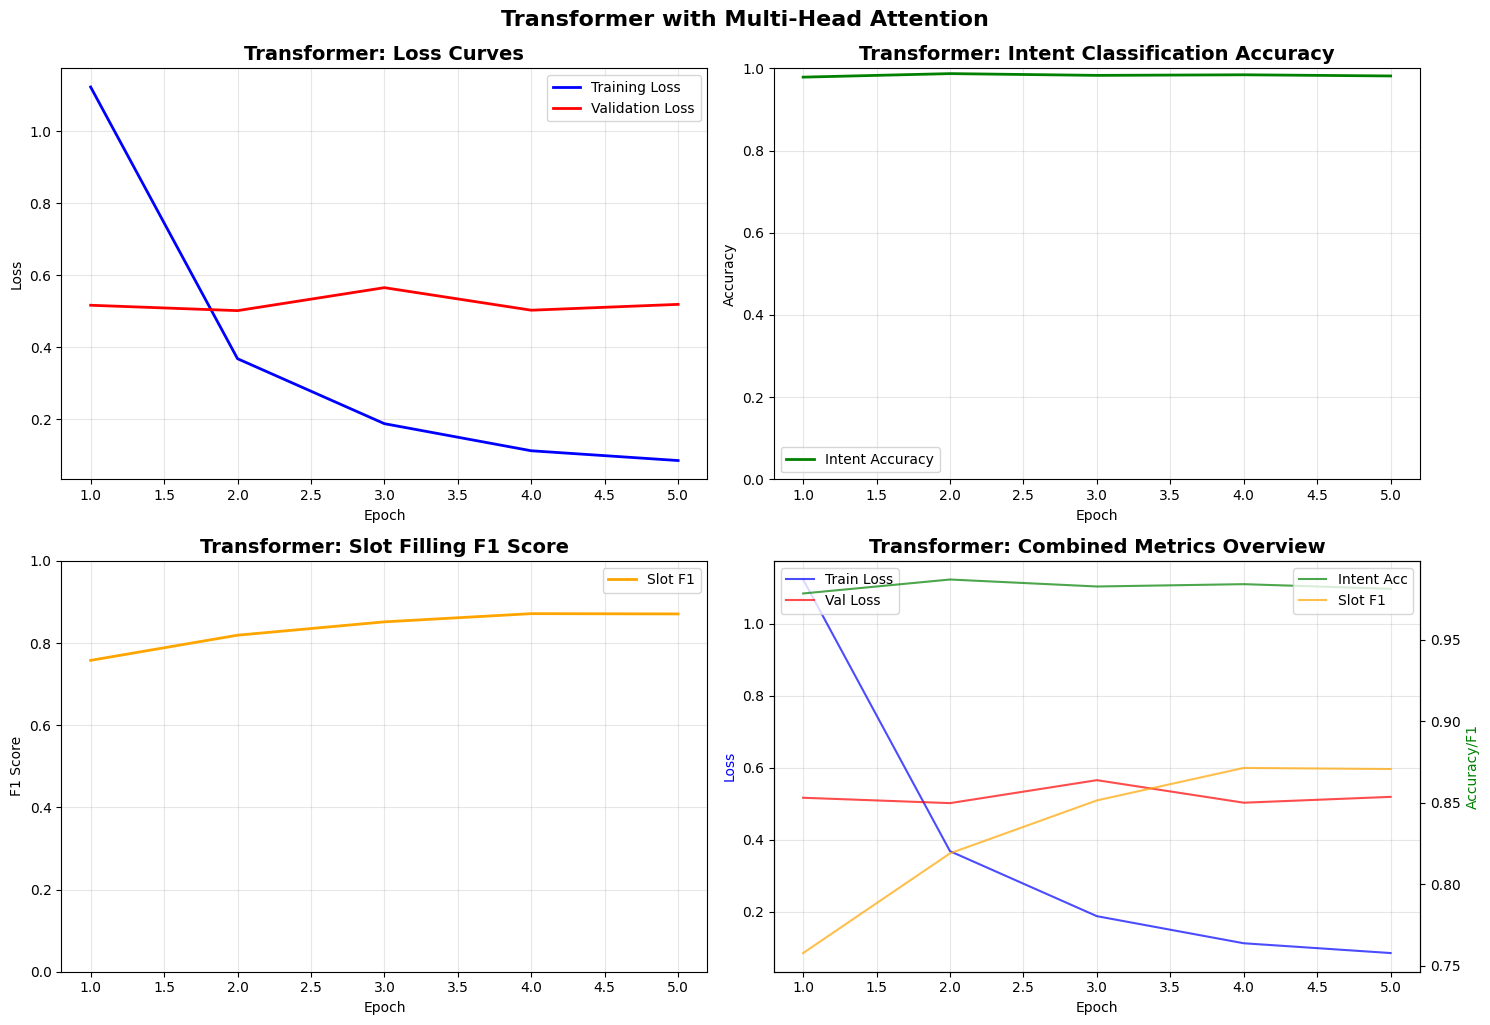

In [64]:
# Transformer (Multi-Head Attention) Training Curves
if 'history2' in locals():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history2['train_loss']) + 1)
    
    # Loss curves
    ax1.plot(epochs, history2['train_loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history2['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('Transformer: Loss Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Intent Accuracy
    ax2.plot(epochs, history2['intent_acc'], 'g-', label='Intent Accuracy', linewidth=2)
    ax2.set_title('Transformer: Intent Classification Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Slot F1 Score
    ax3.plot(epochs, history2['slot_f1'], 'orange', label='Slot F1', linewidth=2)
    ax3.set_title('Transformer: Slot Filling F1 Score', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('F1 Score')
    ax3.set_ylim(0, 1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Combined metrics
    ax4.plot(epochs, history2['train_loss'], 'b-', label='Train Loss', alpha=0.7)
    ax4.plot(epochs, history2['val_loss'], 'r-', label='Val Loss', alpha=0.7)
    ax4_twin = ax4.twinx()
    ax4_twin.plot(epochs, history2['intent_acc'], 'g-', label='Intent Acc', alpha=0.7)
    ax4_twin.plot(epochs, history2['slot_f1'], 'orange', label='Slot F1', alpha=0.7)
    ax4.set_title('Transformer: Combined Metrics Overview', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss', color='blue')
    ax4_twin.set_ylabel('Accuracy/F1', color='green')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Transformer with Multi-Head Attention', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
else:
    print("Transformer training history not available. Please run Transformer training first.")

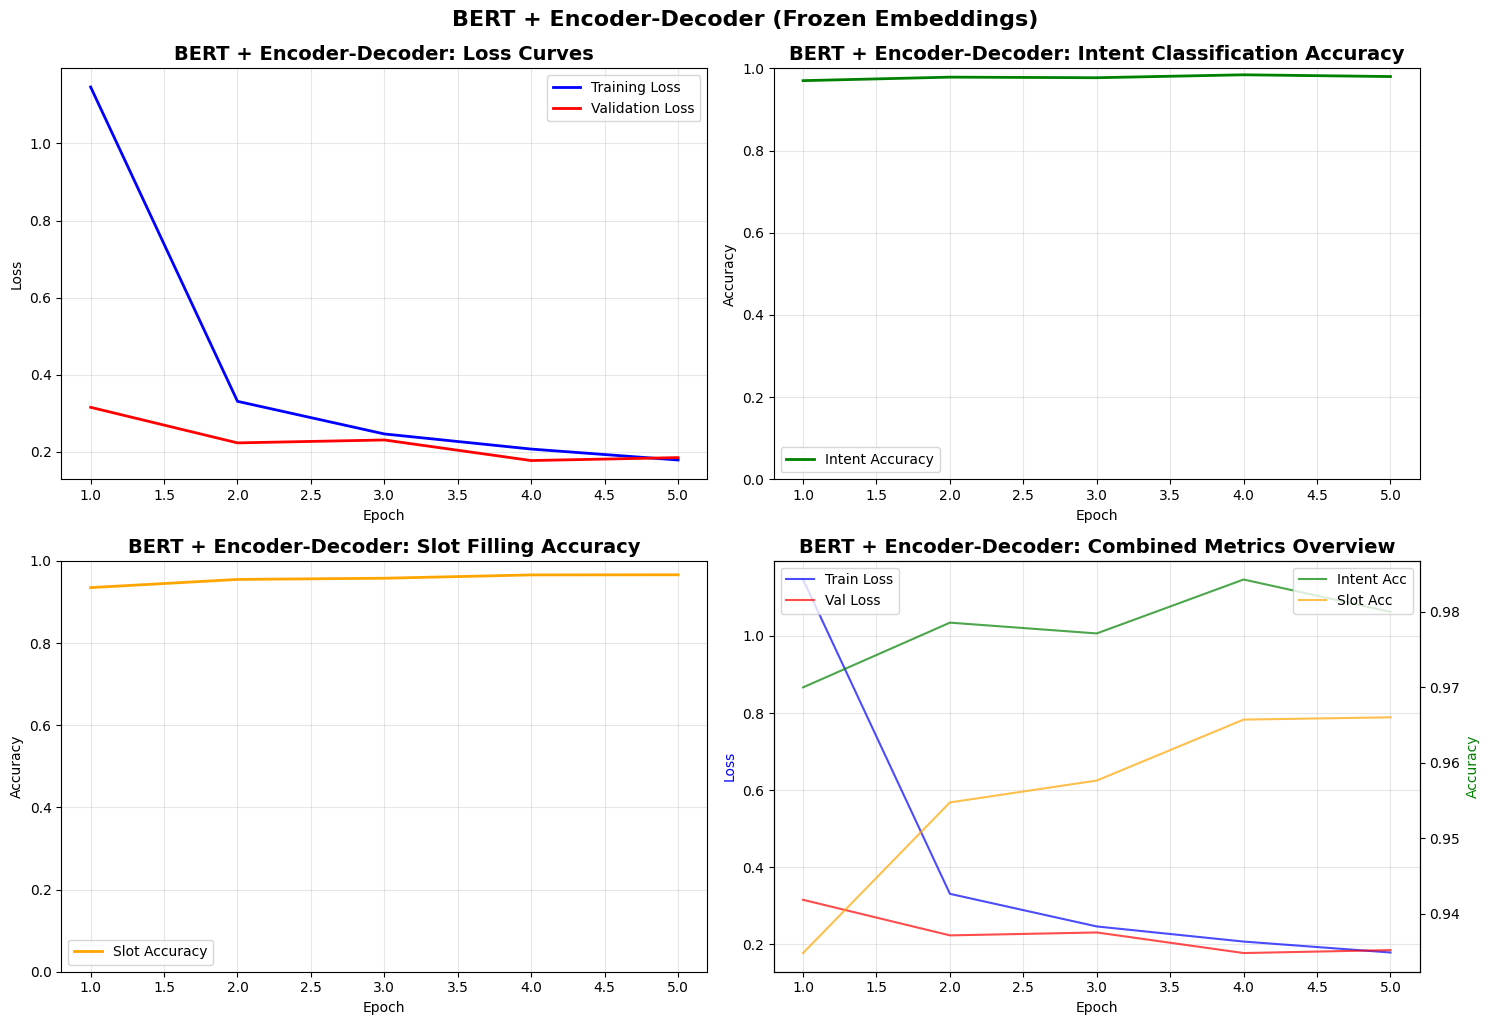

In [65]:
# BERT + Encoder-Decoder Training Curves
if 'history3' in locals():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history3['train_loss']) + 1)
    
    # Loss curves
    ax1.plot(epochs, history3['train_loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history3['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('BERT + Encoder-Decoder: Loss Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Intent Accuracy
    ax2.plot(epochs, history3['intent_acc'], 'g-', label='Intent Accuracy', linewidth=2)
    ax2.set_title('BERT + Encoder-Decoder: Intent Classification Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Slot Accuracy (Note: Model 3 tracks slot accuracy instead of F1)
    ax3.plot(epochs, history3['slot_acc'], 'orange', label='Slot Accuracy', linewidth=2)
    ax3.set_title('BERT + Encoder-Decoder: Slot Filling Accuracy', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy')
    ax3.set_ylim(0, 1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Combined metrics
    ax4.plot(epochs, history3['train_loss'], 'b-', label='Train Loss', alpha=0.7)
    ax4.plot(epochs, history3['val_loss'], 'r-', label='Val Loss', alpha=0.7)
    ax4_twin = ax4.twinx()
    ax4_twin.plot(epochs, history3['intent_acc'], 'g-', label='Intent Acc', alpha=0.7)
    ax4_twin.plot(epochs, history3['slot_acc'], 'orange', label='Slot Acc', alpha=0.7)
    ax4.set_title('BERT + Encoder-Decoder: Combined Metrics Overview', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss', color='blue')
    ax4_twin.set_ylabel('Accuracy', color='green')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('BERT + Encoder-Decoder (Frozen Embeddings)', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
else:
    print("BERT + Encoder-Decoder training history not available. Please run BERT + Encoder-Decoder training first.")

### Note on BERT + Encoder-Decoder Metrics

**Important:** The BERT + Encoder-Decoder model tracks **slot accuracy** instead of **slot F1** during training due to the different evaluation approach needed for BERT's subword tokenization. The slot accuracy represents the percentage of correctly classified slot labels at the token level, excluding ignored tokens (-100) used for subword alignment.

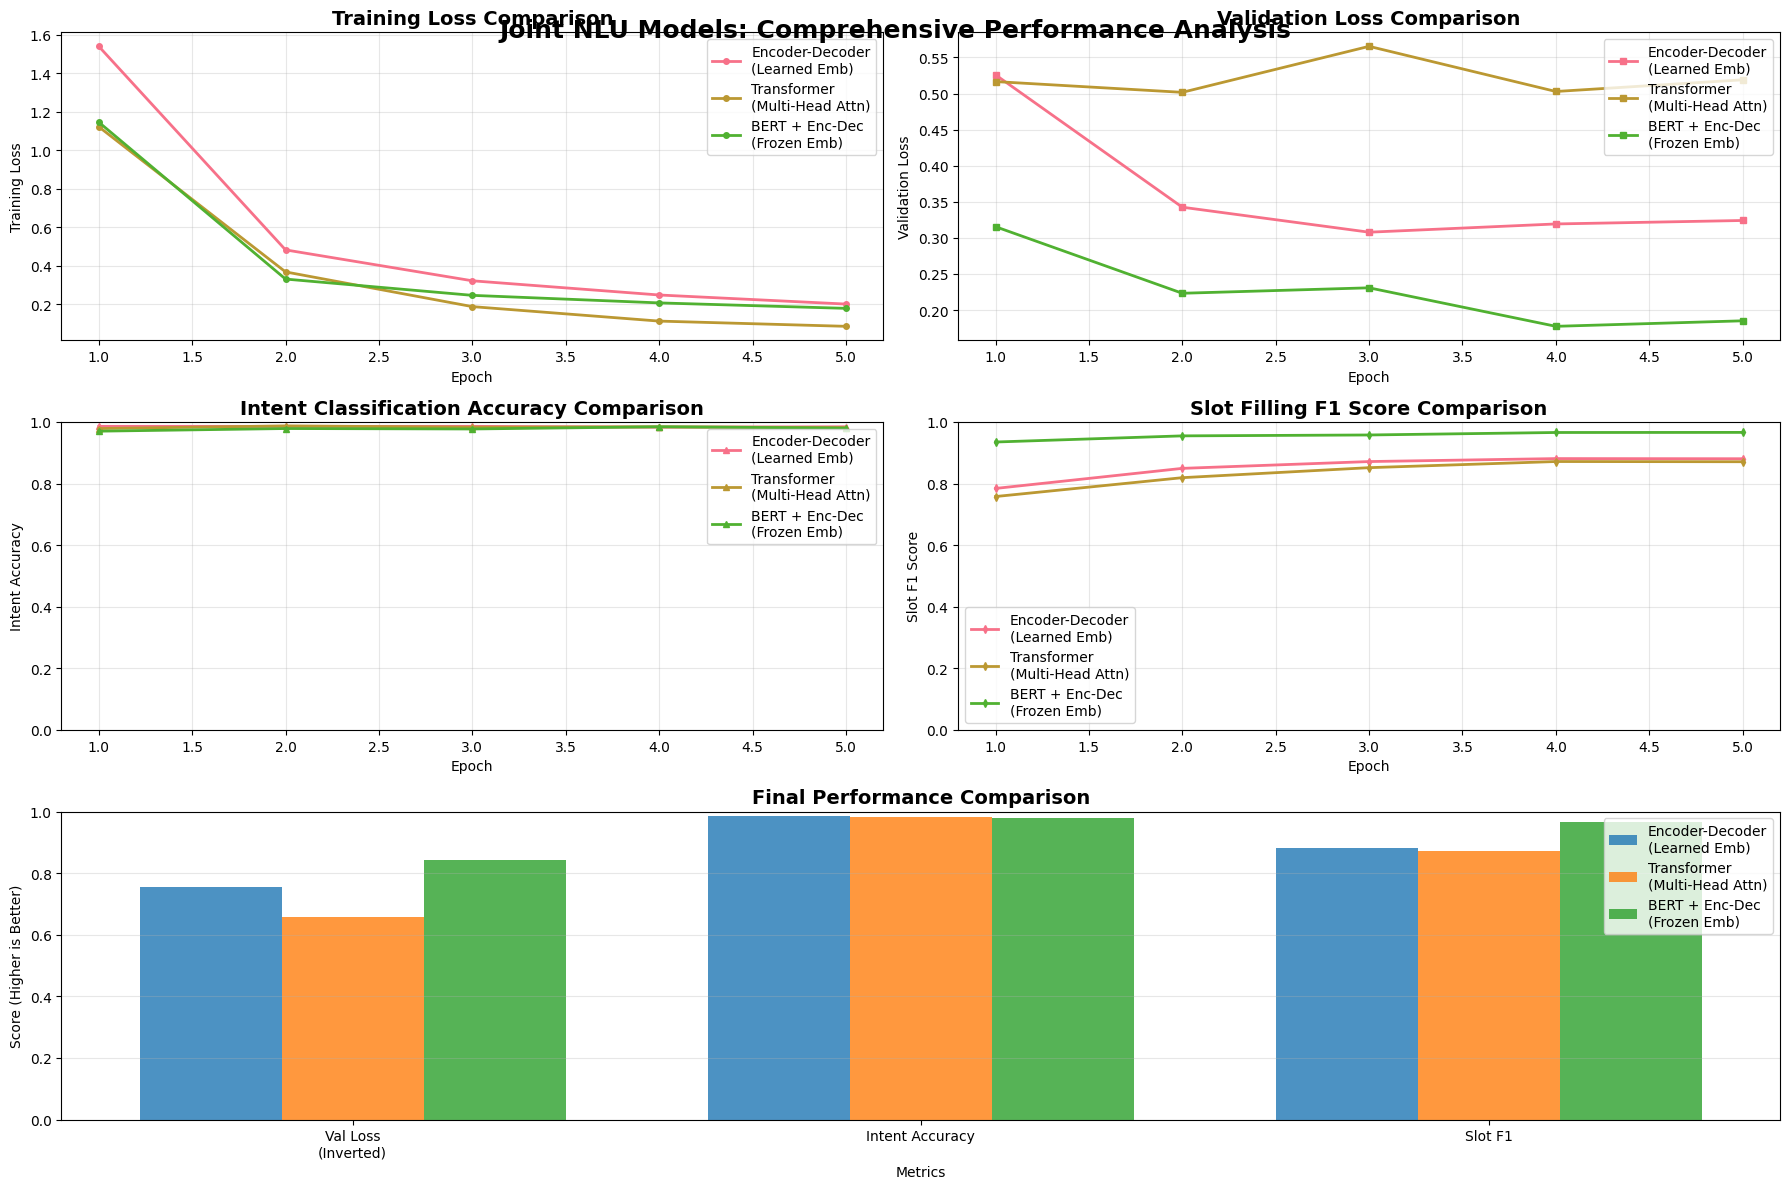


FINAL PERFORMANCE SUMMARY

Encoder-Decoder
(Learned Emb):
  Final Validation Loss: 0.3241
  Final Intent Accuracy: 0.9843
  Final Slot F1 Score:   0.8805

Transformer
(Multi-Head Attn):
  Final Validation Loss: 0.5191
  Final Intent Accuracy: 0.9814
  Final Slot F1 Score:   0.8708

BERT + Enc-Dec
(Frozen Emb):
  Final Validation Loss: 0.1850
  Final Intent Accuracy: 0.9800
  Final Slot F1 Score:   0.9660


In [66]:
# Model Comparison Charts
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 2, figure=fig)

# Check which histories are available
models_available = {}
if 'history1' in locals():
    models_available['Encoder-Decoder\n(Learned Emb)'] = history1
if 'history2' in locals():
    models_available['Transformer\n(Multi-Head Attn)'] = history2
if 'history3' in locals():
    # For BERT model, we need to adapt the history format since it uses slot_acc instead of slot_f1
    history3_adapted = {
        'train_loss': history3['train_loss'],
        'val_loss': history3['val_loss'],
        'intent_acc': history3['intent_acc'],
        'slot_f1': history3['slot_acc']  # Use slot accuracy as proxy for F1
    }
    models_available['BERT + Enc-Dec\n(Frozen Emb)'] = history3_adapted

if models_available:
    # Training Loss Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    for name, history in models_available.items():
        epochs = range(1, len(history['train_loss']) + 1)
        ax1.plot(epochs, history['train_loss'], label=name, linewidth=2, marker='o', markersize=4)
    ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Validation Loss Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    for name, history in models_available.items():
        epochs = range(1, len(history['val_loss']) + 1)
        ax2.plot(epochs, history['val_loss'], label=name, linewidth=2, marker='s', markersize=4)
    ax2.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Intent Accuracy Comparison
    ax3 = fig.add_subplot(gs[1, 0])
    for name, history in models_available.items():
        epochs = range(1, len(history['intent_acc']) + 1)
        ax3.plot(epochs, history['intent_acc'], label=name, linewidth=2, marker='^', markersize=4)
    ax3.set_title('Intent Classification Accuracy Comparison', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Intent Accuracy')
    ax3.set_ylim(0, 1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Slot F1 Comparison
    ax4 = fig.add_subplot(gs[1, 1])
    for name, history in models_available.items():
        epochs = range(1, len(history['slot_f1']) + 1)
        ax4.plot(epochs, history['slot_f1'], label=name, linewidth=2, marker='d', markersize=4)
    ax4.set_title('Slot Filling F1 Score Comparison', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Slot F1 Score')
    ax4.set_ylim(0, 1)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Performance Summary Bar Chart
    ax5 = fig.add_subplot(gs[2, :])
    
    # Get final metrics for each model
    final_metrics = {}
    for name, history in models_available.items():
        final_metrics[name] = {
            'Final Val Loss': history['val_loss'][-1],
            'Final Intent Acc': history['intent_acc'][-1],
            'Final Slot F1': history['slot_f1'][-1]
        }
    
    # Create grouped bar chart
    metric_names = ['Final Val Loss', 'Final Intent Acc', 'Final Slot F1']
    x = np.arange(len(metric_names))
    width = 0.25  # Adjust width for 3 models
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(models_available)]
    for i, (model_name, metrics) in enumerate(final_metrics.items()):
        values = [metrics[metric] for metric in metric_names]
        # Normalize loss for better visualization (invert and scale)
        values[0] = 1 / (1 + values[0])  # Transform loss to 0-1 scale
        offset = (i - len(final_metrics)/2 + 0.5) * width
        ax5.bar(x + offset, values, width, label=model_name, color=colors[i], alpha=0.8)
    
    ax5.set_title('Final Performance Comparison', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Metrics')
    ax5.set_ylabel('Score (Higher is Better)')
    ax5.set_xticks(x)
    ax5.set_xticklabels(['Val Loss\n(Inverted)', 'Intent Accuracy', 'Slot F1'])
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.suptitle('Joint NLU Models: Comprehensive Performance Analysis', fontsize=18, fontweight='bold', y=0.98)
    plt.show()
    
    # Print numerical summary
    print("\n" + "="*60)
    print("FINAL PERFORMANCE SUMMARY")
    print("="*60)
    for model_name, metrics in final_metrics.items():
        print(f"\n{model_name}:")
        print(f"  Final Validation Loss: {metrics['Final Val Loss']:.4f}")
        print(f"  Final Intent Accuracy: {metrics['Final Intent Acc']:.4f}")
        print(f"  Final Slot F1 Score:   {metrics['Final Slot F1']:.4f}")
else:
    print("No model training histories available for comparison.")

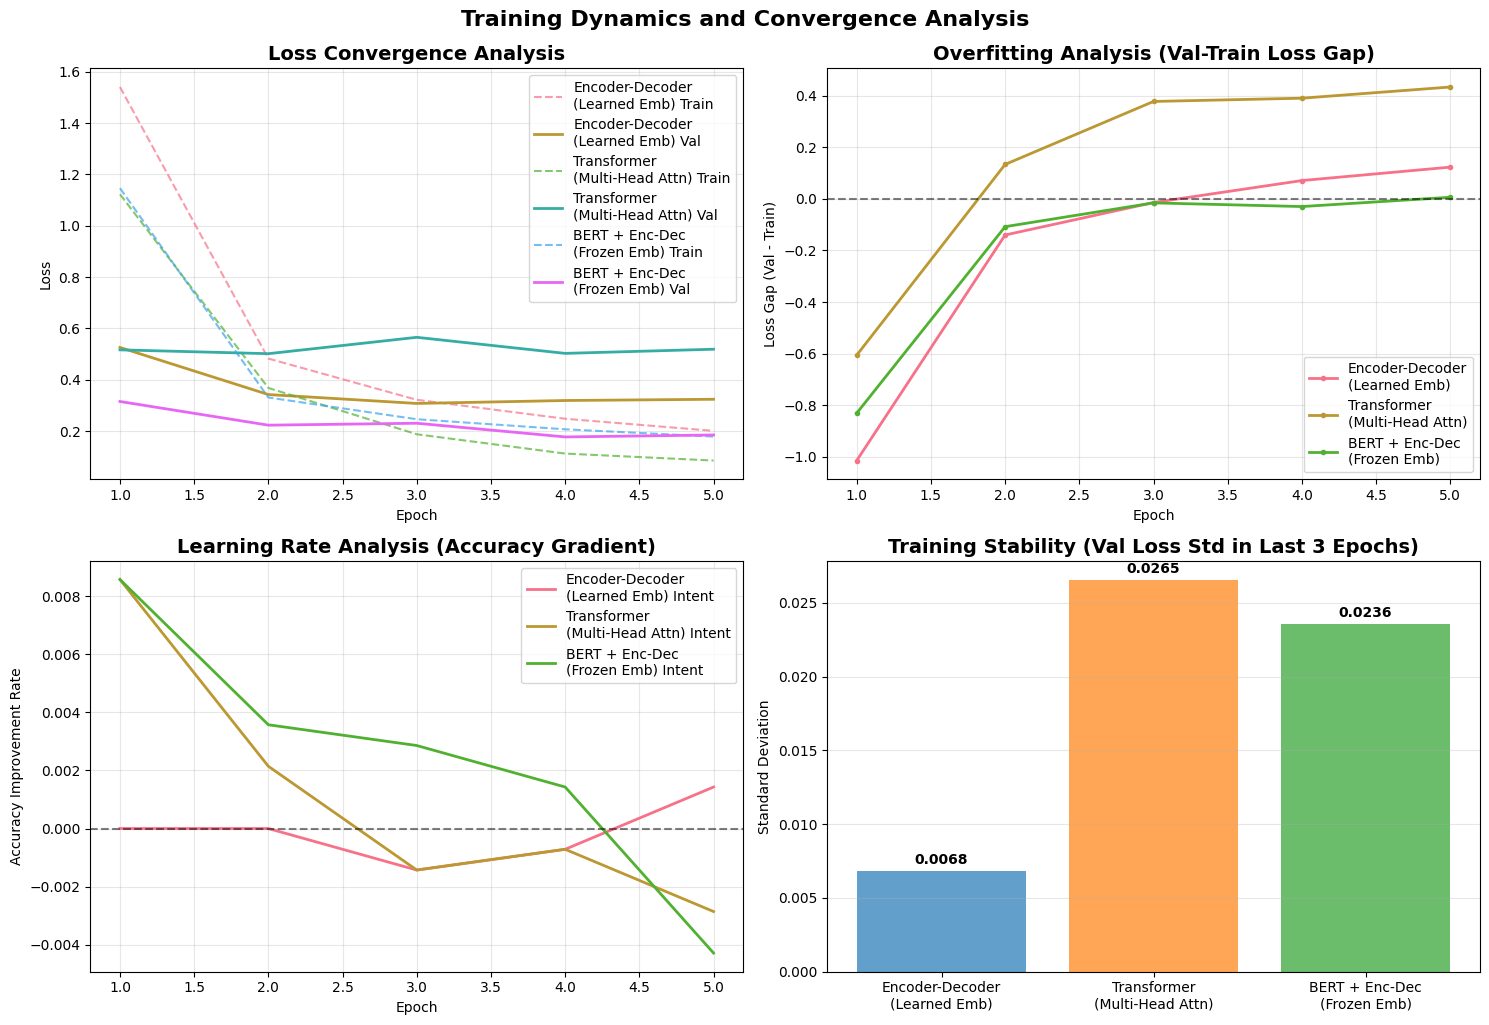

In [67]:
# Convergence Analysis
if models_available:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss convergence (Train vs Validation)
    ax = axes[0, 0]
    for name, history in models_available.items():
        epochs = range(1, len(history['train_loss']) + 1)
        train_loss = np.array(history['train_loss'])
        val_loss = np.array(history['val_loss'])
        
        ax.plot(epochs, train_loss, '--', label=f'{name} Train', alpha=0.7)
        ax.plot(epochs, val_loss, '-', label=f'{name} Val', linewidth=2)
    
    ax.set_title('Loss Convergence Analysis', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Overfitting Detection (Train-Val Gap)
    ax = axes[0, 1]
    for name, history in models_available.items():
        epochs = range(1, len(history['train_loss']) + 1)
        gap = np.array(history['val_loss']) - np.array(history['train_loss'])
        ax.plot(epochs, gap, label=name, linewidth=2, marker='o', markersize=3)
    
    ax.set_title('Overfitting Analysis (Val-Train Loss Gap)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss Gap (Val - Train)')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Learning Rate vs Performance
    ax = axes[1, 0]
    for name, history in models_available.items():
        epochs = range(1, len(history['intent_acc']) + 1)
        intent_acc = np.array(history['intent_acc'])
        slot_f1 = np.array(history['slot_f1'])
        
        # Calculate improvement rate (derivative approximation)
        intent_improvement = np.gradient(intent_acc)
        ax.plot(epochs, intent_improvement, label=f'{name} Intent', linewidth=2)
    
    ax.set_title('Learning Rate Analysis (Accuracy Gradient)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy Improvement Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Stability Analysis (Standard deviation of last few epochs)
    ax = axes[1, 1]
    stability_data = []
    model_names = []
    
    for name, history in models_available.items():
        # Calculate stability over last 3 epochs
        if len(history['val_loss']) >= 3:
            last_losses = history['val_loss'][-3:]
            stability = np.std(last_losses)
            stability_data.append(stability)
            model_names.append(name)
    
    if stability_data:
        bars = ax.bar(model_names, stability_data, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(stability_data)], alpha=0.7)
        ax.set_title('Training Stability (Val Loss Std in Last 3 Epochs)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Standard Deviation')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, value in zip(bars, stability_data):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stability_data)*0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.suptitle('Training Dynamics and Convergence Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

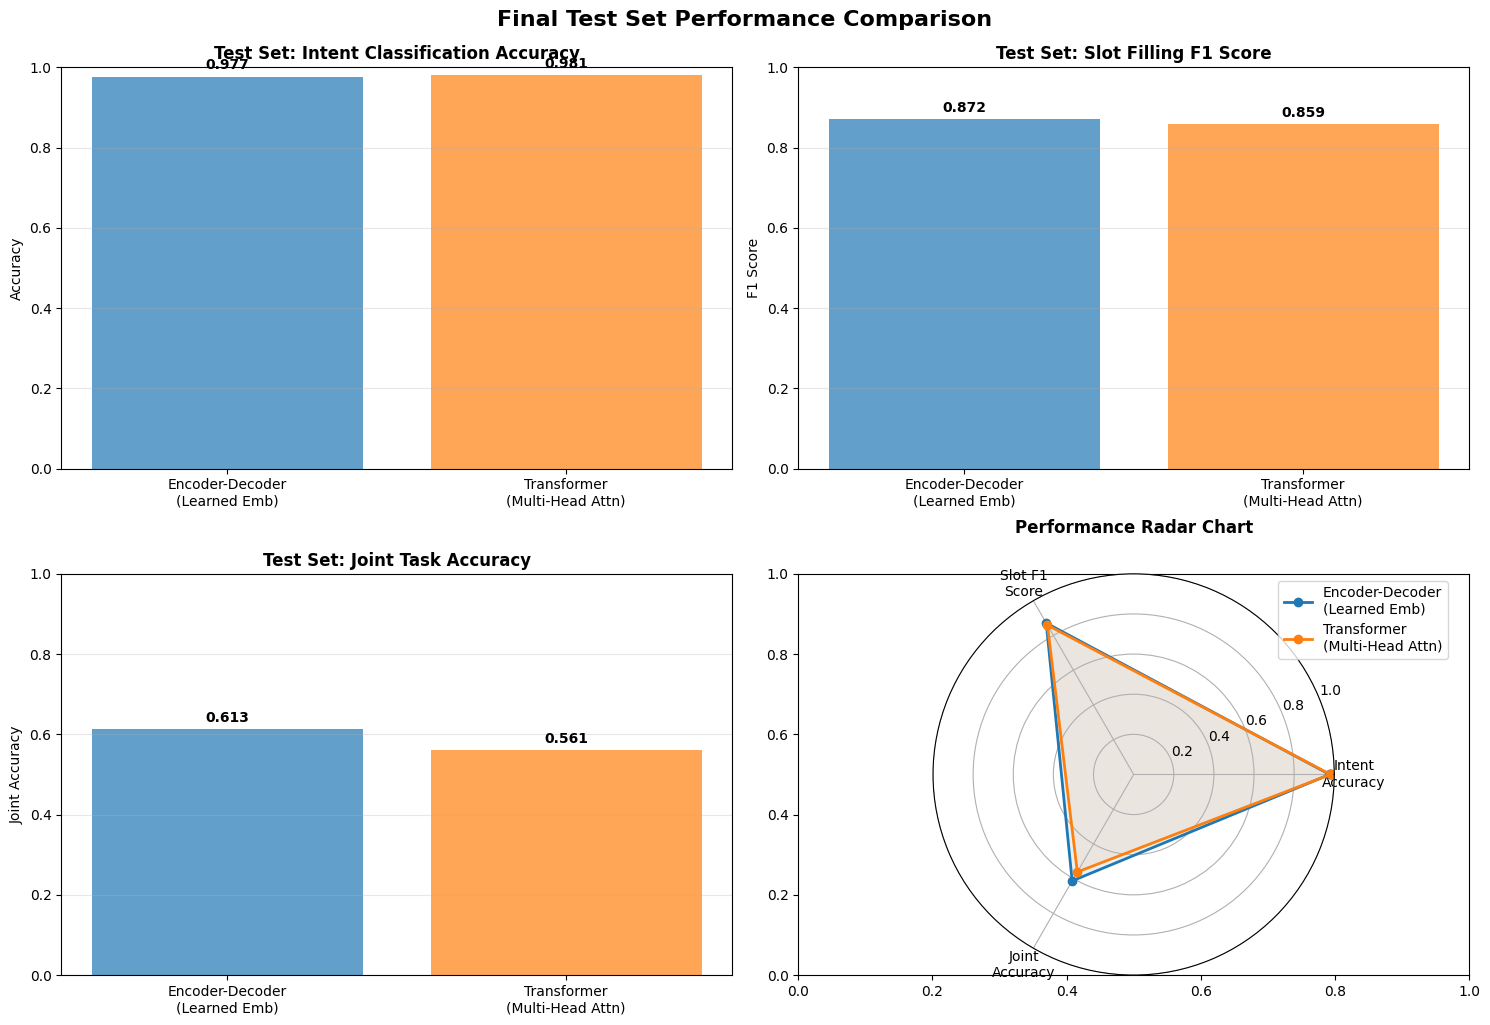


COMPREHENSIVE TEST PERFORMANCE COMPARISON
Model                     Intent Acc   Slot F1    Joint Acc   
--------------------------------------------------------------------------------
Encoder-Decoder
(Learned Emb) 0.9771       0.8716     0.6129      
Transformer
(Multi-Head Attn) 0.9814       0.8592     0.5614      

🏆 Best Overall Performance: Encoder-Decoder
(Learned Emb)
   Joint Accuracy: 0.6129


In [68]:
# Test Performance Visualization
test_results = {}

# Collect test results if available
if 'test_metrics1' in locals():
    test_results['Encoder-Decoder\n(Learned Emb)'] = test_metrics1
if 'test_metrics2' in locals():
    test_results['Transformer\n(Multi-Head Attn)'] = test_metrics2

# Note: BERT + Encoder-Decoder evaluation is done differently, so we'll add a placeholder
# You can manually add BERT model results here after running the evaluation

if test_results:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    models = list(test_results.keys())
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(models)]
    
    # Intent Accuracy
    intent_acc = [test_results[model]['intent_accuracy'] for model in models]
    bars1 = ax1.bar(models, intent_acc, color=colors, alpha=0.7)
    ax1.set_title('Test Set: Intent Classification Accuracy', fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, value in zip(bars1, intent_acc):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Slot F1 Score
    slot_f1 = [test_results[model]['slot_f1'] for model in models]
    bars2 = ax2.bar(models, slot_f1, color=colors, alpha=0.7)
    ax2.set_title('Test Set: Slot Filling F1 Score', fontweight='bold')
    ax2.set_ylabel('F1 Score')
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, value in zip(bars2, slot_f1):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Joint Accuracy
    joint_acc = [test_results[model]['joint_accuracy'] for model in models]
    bars3 = ax3.bar(models, joint_acc, color=colors, alpha=0.7)
    ax3.set_title('Test Set: Joint Task Accuracy', fontweight='bold')
    ax3.set_ylabel('Joint Accuracy')
    ax3.set_ylim(0, 1)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, value in zip(bars3, joint_acc):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Comprehensive comparison radar chart
    ax4 = plt.subplot(2, 2, 4, projection='polar')
    
    # Metrics for radar chart
    metrics = ['Intent\nAccuracy', 'Slot F1\nScore', 'Joint\nAccuracy']
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))  # Complete the circle
    
    for i, model in enumerate(models):
        values = [intent_acc[i], slot_f1[i], joint_acc[i]]
        values += [values[0]]  # Complete the circle
        
        ax4.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
        ax4.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(metrics)
    ax4.set_ylim(0, 1)
    ax4.set_title('Performance Radar Chart', y=1.08, fontweight='bold')
    ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax4.grid(True)
    
    plt.tight_layout()
    plt.suptitle('Final Test Set Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # Print comprehensive comparison table
    print("\n" + "="*80)
    print("COMPREHENSIVE TEST PERFORMANCE COMPARISON")
    print("="*80)
    print(f"{'Model':<25} {'Intent Acc':<12} {'Slot F1':<10} {'Joint Acc':<12}")
    print("-" * 80)
    
    for i, model in enumerate(models):
        print(f"{model:<25} {intent_acc[i]:<12.4f} {slot_f1[i]:<10.4f} {joint_acc[i]:<12.4f}")
    
    # Find and highlight best performing model
    best_joint = max(range(len(joint_acc)), key=lambda i: joint_acc[i])
    print(f"\n🏆 Best Overall Performance: {models[best_joint]}")
    print(f"   Joint Accuracy: {joint_acc[best_joint]:.4f}")
    
else:
    print("No test results available yet. Run model evaluations first to see performance comparison.")

In [69]:
# Advanced Performance Analysis
from sklearn.metrics import confusion_matrix, classification_report
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    """Plot confusion matrix with proper formatting."""
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')

# Function to generate detailed error analysis for any model
def analyze_model_errors(model, test_loader, model_name, intent_vocab_inv=None, slot_vocab_inv=None):
    """Analyze model errors and generate confusion matrices."""
    print(f"\n{'='*60}")
    print(f"DETAILED ERROR ANALYSIS: {model_name}")
    print(f"{'='*60}")
    
    model.eval()
    all_intent_preds = []
    all_intent_labels = []
    all_slot_preds = []
    all_slot_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Analyzing {model_name}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intent_labels = batch['intent_label'].to(device)
            slot_labels = batch['slot_labels'].to(device)
            
            # Forward pass
            intent_logits, slot_logits = model(input_ids, attention_mask)
            
            # Get predictions
            intent_preds = torch.argmax(intent_logits, dim=1)
            slot_preds = torch.argmax(slot_logits, dim=2)
            
            all_intent_preds.extend(intent_preds.cpu().numpy())
            all_intent_labels.extend(intent_labels.cpu().numpy())
            
            # Flatten slot predictions (exclude padding)
            for i in range(slot_preds.size(0)):
                pred_seq = slot_preds[i].cpu().numpy()
                label_seq = slot_labels[i].cpu().numpy()
                # Only include non-padding tokens
                valid_positions = label_seq != slot_vocab.get('<PAD>', 0)
                all_slot_preds.extend(pred_seq[valid_positions])
                all_slot_labels.extend(label_seq[valid_positions])
    
    # Intent confusion matrix
    if intent_vocab_inv:
        intent_cm = confusion_matrix(all_intent_labels, all_intent_preds)
        intent_classes = [intent_vocab_inv.get(i, f'Class_{i}') for i in range(len(intent_vocab_inv))]
        
        plt.figure(figsize=(10, 8))
        plot_confusion_matrix(intent_cm, intent_classes, 
                            f'{model_name}: Intent Classification Confusion Matrix')
        plt.tight_layout()
        plt.show()
        
        # Intent classification report
        print(f"\nIntent Classification Report ({model_name}):")
        print(classification_report(all_intent_labels, all_intent_preds, 
                                  target_names=intent_classes, digits=4))
    
    # Slot filling confusion matrix (show top 10 most common classes)
    if slot_vocab_inv:
        slot_cm = confusion_matrix(all_slot_labels, all_slot_preds)
        unique_labels = sorted(set(all_slot_labels + all_slot_preds))[:10]  # Top 10
        slot_classes = [slot_vocab_inv.get(i, f'Slot_{i}') for i in unique_labels]
        
        # Reduce confusion matrix to top classes
        reduced_cm = slot_cm[np.ix_(unique_labels, unique_labels)]
        
        plt.figure(figsize=(12, 10))
        plot_confusion_matrix(reduced_cm, slot_classes,
                            f'{model_name}: Slot Filling Confusion Matrix (Top 10 Classes)')
        plt.tight_layout()
        plt.show()

# Create inverse vocabularies for analysis
if 'intent_vocab' in locals():
    intent_vocab_inv = {v: k for k, v in intent_vocab.items()}
else:
    intent_vocab_inv = None

if 'slot_vocab' in locals():
    slot_vocab_inv = {v: k for k, v in slot_vocab.items()}
else:
    slot_vocab_inv = None

print("Advanced analysis functions loaded!")
print("\nTo run detailed error analysis, use:")
print("analyze_model_errors(model1, test_loader, 'Encoder-Decoder (Learned Embeddings)', intent_vocab_inv, slot_vocab_inv)")
print("analyze_model_errors(model2, test_loader, 'Transformer (Multi-Head Attention)', intent_vocab_inv, slot_vocab_inv)")
print("\nNote: Make sure to run the model training and evaluation cells first!")

Advanced analysis functions loaded!

To run detailed error analysis, use:
analyze_model_errors(model1, test_loader, 'Encoder-Decoder (Learned Embeddings)', intent_vocab_inv, slot_vocab_inv)
analyze_model_errors(model2, test_loader, 'Transformer (Multi-Head Attention)', intent_vocab_inv, slot_vocab_inv)

Note: Make sure to run the model training and evaluation cells first!


## 6. Model Comparison Summary

In [70]:
import pandas as pd

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Encoder-Decoder (Learned)', 'Transformer (Multi-Head)', 'BERT + Encoder-Decoder'],
    'Parameters': [
        f"{sum(p.numel() for p in model1.parameters()):,}",
        f"{sum(p.numel() for p in model2.parameters()):,}",
        f"{sum(p.numel() for p in model3.parameters() if p.requires_grad):,} (trainable)"
    ],
    'Intent Acc': [
        f"{test_metrics1['intent_accuracy']:.4f}" if 'test_metrics1' in dir() else 'N/A',
        f"{test_metrics2['intent_accuracy']:.4f}" if 'test_metrics2' in dir() else 'N/A',
        'See above'
    ],
    'Slot F1': [
        f"{test_metrics1['slot_f1']:.4f}" if 'test_metrics1' in dir() else 'N/A',
        f"{test_metrics2['slot_f1']:.4f}" if 'test_metrics2' in dir() else 'N/A',
        'See above'
    ]
})

print("Model Comparison:")
print(comparison.to_string(index=False))

Model Comparison:
                    Model            Parameters Intent Acc   Slot F1
Encoder-Decoder (Learned)             4,608,272     0.9771    0.8716
 Transformer (Multi-Head)             6,656,336     0.9814    0.8592
   BERT + Encoder-Decoder 1,110,608 (trainable)  See above See above


## 7. Save Models

In [71]:
# Save model weights
torch.save(model1.state_dict(), 'encoder_decoder_nlu.pth')
torch.save(model2.state_dict(), 'transformer_nlu.pth')

# For BERT + Encoder-Decoder, only save GRU weights (BERT is frozen)
model3_state = {
    'encoder': model3.encoder.state_dict(),
    'decoder': model3.decoder.state_dict(),
    'encoder_to_decoder': model3.encoder_to_decoder.state_dict(),
    'intent_classifier': model3.intent_classifier.state_dict(),
    'slot_classifier': model3.slot_classifier.state_dict(),
}
torch.save(model3_state, 'bert_encoder_decoder_nlu.pth')

print("Models saved successfully!")

Models saved successfully!
